<a href="https://colab.research.google.com/github/Svasvil/PracticasBigData/blob/Practica%234/SebastianVasquezVillaplana_SC707_Practica4_LN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 04 (5%) Entrega Lección 07, 17:30 horas

1. Explore las distribuciones de algunos atributos (columnas) del data set de su proyecto grupal. (Coordinen entre los integrantes del grupo para que seleccionen atributos distintos). Utilice tablas de frecuencias, resúmenes numéricos, histogramas y "boxplots" para describir el comportamiento de los datos del atributo y comparaciones con las distribuciones de otros atributos. Si es el caso puede crear etiquetas para categorías (como en el caso de género, nivel educativo o la mediana del ingreso de los ejemplos vistos en clase).
  
2. A partir del data set de su proyecto genere un training set y un test set de forma aleatoria (80% training y 20% test).  Luego escoja un atributo cuya distribución ustede piense que deba ser considerada en la construcción de los data sets y genere dos nuevos sets (igual 80% y 20%) y compárelos. (Como se hizo en clase). Igual que en el punto 1 coordinen entre los integrantes del grupo para seleccionar atributos distintos.


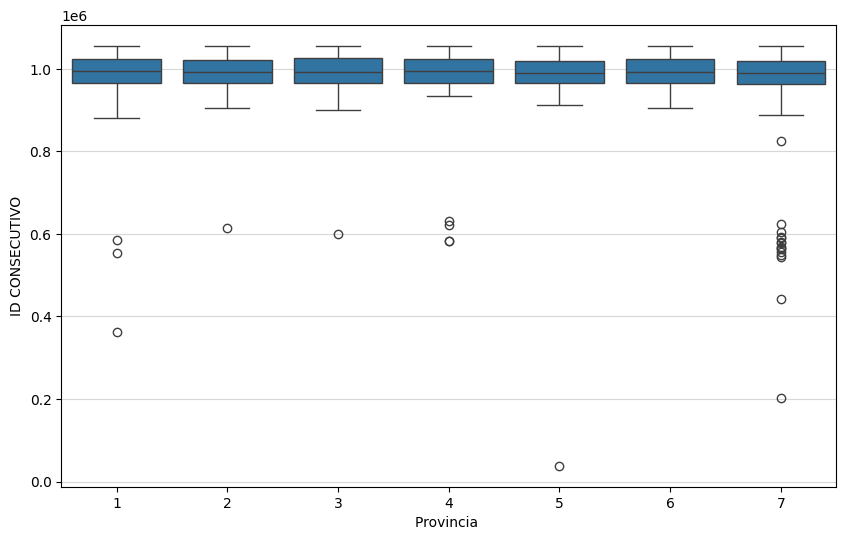

##########


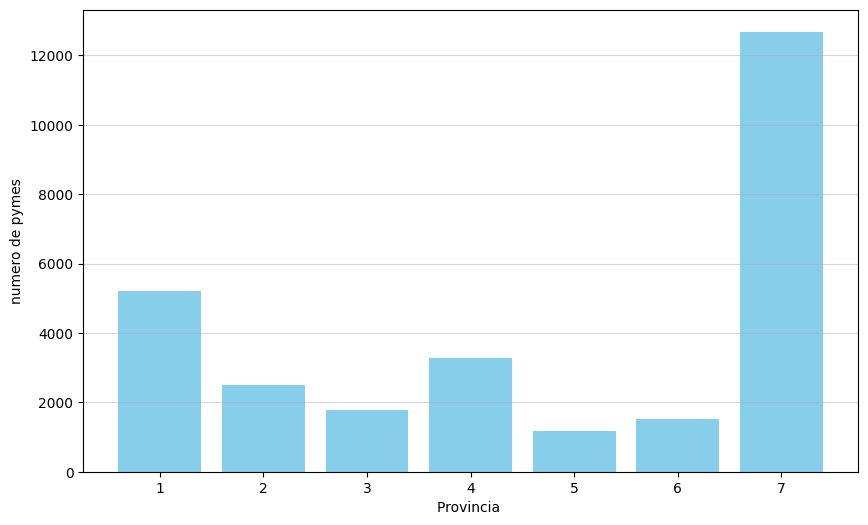

In [2]:
#Punto #1
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.preprocessing import LabelEncoder
Doc = pd.read_csv("/content/Reporte-Mensual-Empresas-Activas-al-30-de-setiembre-2025.xlsx.csv",header =1 )

for col in Doc.select_dtypes(include=['object']).columns:
  le=LabelEncoder()
  Doc[col]=le.fit_transform(Doc[col].astype(str))
Doc['PROVINCIA_1_7'] = Doc['PROVINCIA'] + 1

#Boxplox

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='PROVINCIA_1_7',
    y='ID CONSECUTIVO',
    data=Doc
)
plt.xlabel('Provincia ')
plt.grid(axis='y', alpha=0.5)
plt.show()
#histograma
print("##########")
plt.figure(figsize=(10, 6))
frecuenciaProvicnias = Doc['PROVINCIA_1_7'].value_counts().sort_index()
plt.bar(frecuenciaProvicnias.index.astype(str), frecuenciaProvicnias.values, color='skyblue')
plt.xlabel('Provincia ')
plt.ylabel('numero de pymes')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [9]:
#Punto #2
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split # Esta es la libreria que usamos para hacer los traingn sets

Doc = pd.read_csv("/content/Reporte-Mensual-Empresas-Activas-al-30-de-setiembre-2025.xlsx.csv",header =1 )
Datos = Doc.copy()
train_rand, test_rand = train_test_split(
    Datos,
    test_size=0.2,
    random_state=42
)

print(f"Tamano de entreno: {len(train_rand)}") # Estos basicamente son los datos que se usaron para el set completo ,el total de datos
print(f"Tamano de test: {len(test_rand)}") # Y estos son los datos que usaron para la prueba especificamente


Datos2 = Doc.copy()
train_strat, test_strat = train_test_split(
    Datos2,
    test_size=0.2,
    random_state=42,
    stratify=Datos2['PROVINCIA']
)

print(f"Tamaño de Entrenamiento: {len(train_strat)}") # al igual que el otro estos datos son todos aquellos que se usan para entrenar el modelo
print(f"Tamaño de Prueba: {len(test_strat)}") # y estos son los datos que vamos a usar de prueba



Frec = Doc['PROVINCIA'].value_counts(normalize=True).sort_index()
DisPrueba = test_rand['PROVINCIA'].value_counts(normalize=True).sort_index()

comparacion = pd.DataFrame({
    'Original': Frec,
    'Aleatorio': DisPrueba,
})

display(comparacion)

Tamano de entreno: 22540
Tamano de test: 5636
Tamaño de Entrenamiento: 22540
Tamaño de Prueba: 5636


,Original,Aleatorio
PROVINCIA,,
Alajuela,0.185264,0.186302
Cartago,0.088799,0.084989
Guanacaste,0.063423,0.064762
Heredia,0.116482,0.118524
Limón,0.042057,0.040809
Puntarenas,0.053876,0.056600
San José,0.450099,0.448013
